<a href="https://colab.research.google.com/github/aseel1/Deep-learning/blob/main/HW-3/HW3_PT2_322512690_212393532_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Assignment 3 - Part 2
### Latent Space Visualization

Student 1: Rajaa Haj 322512690

Student 2: Aseel Shaheen 212393532

# Imports

In [1]:
import torch
import numpy as np
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from mpl_toolkits.axes_grid1 import ImageGrid
from torchvision.utils import save_image, make_grid
import torch.nn.functional as F
import random
import os
import imageio
import numpy as np

# Preprocessing

In [2]:
# create a transofrm to apply to each datapoint
transform = transforms.Compose([transforms.ToTensor()])

# download the MNIST datasets
path = '~/datasets'
train_dataset = MNIST(path, transform=transform, download=True)
test_dataset  = MNIST(path, transform=transform, download=True)

# create train and test dataloaders
batch_size = 100
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:11<00:00, 881kB/s] 


Extracting /root/datasets/MNIST/raw/train-images-idx3-ubyte.gz to /root/datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]


Extracting /root/datasets/MNIST/raw/train-labels-idx1-ubyte.gz to /root/datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.05MB/s]


Extracting /root/datasets/MNIST/raw/t10k-images-idx3-ubyte.gz to /root/datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 7.54MB/s]


Extracting /root/datasets/MNIST/raw/t10k-labels-idx1-ubyte.gz to /root/datasets/MNIST/raw



# Encoder Class

The encoder consists of :

*   Two fully connected layers: <br>
    1) **fc1**: maps the input data (input_dim) to the hidden layer (hidden_dim).<br>
    2) **fc2:** maps the hidden layer (hidden_dim) into another hidden layer (hidden_dim). <br>
*   Two output layers:<br>
    1) **mu**: maps the hidden layer (hidden_dim) to the mean of the latent space (latent_dim).<br>
    2)**log_var:** maps the hidden layer (hidden_dim) to the log variance of the latent space(latent_dim). <br>

The encoder takes input data, processes it through two hidden layers with ReLU activations, and then outputs the mean and log variance of the latent space.

In [3]:
class Encoder(nn.Module):

    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc1=nn.Linear(input_dim,hidden_dim)
        self.fc2=nn.Linear(hidden_dim,hidden_dim)
        # get the mean of the latent space
        self.mu=nn.Linear(hidden_dim,latent_dim)
        # get the log var of the latent space
        self.log_var=nn.Linear(hidden_dim,latent_dim)

    def forward(self, x):


      x=F.relu(self.fc1(x))
      x=F.relu(self.fc2(x))
      mu=self.mu(x)
      log_var=self.log_var(x)

      return mu,log_var


# Decoder Class


The decoder consists of :<br>

**Three fully connected (linear) layers :**<br>
1) **fc1:** maps the latent space (latent_dim) to the hidden layer (hidden_dim).<br>
2) **fc2:** maps the hidden layer (hidden_dim) to another hidden layer (hidden_dim).<br>
3) **fc3:** maps the hidden layer (hidden_dim) to the output layer (output_dim).<br>


The decoder takes a sample from the latent space, processes it through two hidden layers with ReLU activations, and then maps it to the output dimension using a sigmoid activation. The sigmoid ensures the output is in a valid range (for MNIST images).


In [4]:
class Decoder(nn.Module):

    def __init__(self, output_dim, hidden_dim, latent_dim):
        super(Decoder, self).__init__()
        self.fc1=nn.Linear(latent_dim,hidden_dim)
        self.fc2=nn.Linear(hidden_dim,hidden_dim)
        self.fc3=nn.Linear(hidden_dim,output_dim)



    def forward(self, x):
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=torch.sigmoid(self.fc3(x)) # Sigmoid for output in [0,1]

        return x

# Variational Auto Encoder Class



The VAE consist of:<br>


*   Encoder : maps input data to the latent space.
*   Decoder: reconstruct the input data from the latent space.



We use the reparameterization trick as we learned to be able to sample from the latent space .


TODOOOO : !!!!!!!!Explian about why we change the dim to 2 :

In [5]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=2, device=device):
        super(VAE, self).__init__()

        self.device= device
        self.encoder=Encoder(input_dim,hidden_dim,latent_dim)
        self.decoder=Decoder(input_dim,hidden_dim,latent_dim)


    def reparameterize(self,mu,log_var):

        std=torch.exp(0.5*log_var)
        epslion=torch.randn_like(std) # random noise
        z=mu+epslion*std     # compute the latent vector
        return z




    def forward(self, x):
        # write your code here

        x=x.view(x.size(0),-1)   # flatten the input
        mu,logvar=self.encoder(x)  # encoder to get the mu and log_var
        z=self.reparameterize(mu,logvar)  # sample latent vector
        recon_x=self.decoder(z)   # decoder to reconstruct input

        return recon_x,mu,logvar

In [6]:
model = VAE().to(device)
lr=0.001
optimizer = Adam(model.parameters(), lr)

# Loss Function Class


We defined the loss function as described on the assignment where:<br>

x: is the original value . <br>
x_hat: is the reconstructed data from the model.<br>
mean: is the mean of the latent space distribution .<br>
log_var: is the log variance of the latent distribution.<br>


**Note:**
we add the small constant **(1e-10)** on the computation of the BCE to avoid numerical instability when x_hat is close to 0 or 1.


In [7]:
def loss_function(x, x_hat, mean, log_var):

    # compute the Reconstruction Loss
    bce_loss=-torch.sum(x*torch.log(x_hat+ 1e-10)+(1-x)*torch.log(1-x_hat+ 1e-10))

    # compute the KL Divergence
    kld=-0.5*torch.sum(1+log_var-mean.pow(2)-log_var.exp())

    #Total loss
    return bce_loss+kld

# Training Loop

In [8]:
losses=[]
def train(model, optimizer, epochs, device, x_dim=784): # Modify, add the evaluation step after each 10 epochs
    model.train()

    for epoch in range(epochs):
        overall_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            x = x.view(batch_size, x_dim).to(device)

            optimizer.zero_grad()

            x_hat, mean, log_var = model(x)
            loss = loss_function(x, x_hat, mean, log_var)

            overall_loss += loss.item()

            loss.backward()
            optimizer.step()

        avg_loss = overall_loss / (batch_idx * batch_size)
        losses.append(avg_loss)

        print("\tEpoch", epoch + 1, "\tAverage Loss: ", overall_loss/(batch_idx*batch_size))

        # After 10 epochs , generate and plot a digit
        if (epoch+1) % 10 ==0:

          with torch.no_grad():

            z=torch.randn(1,model.decoder.fc1.in_features,device=device)

            generated_digit=model.decoder(z).squeeze().cpu().detach().numpy()

            generated_digit=generated_digit.reshape(28,28)

            # plot the generated digit
            plt.imshow(generated_digit,cmap='gray')
            plt.axis('off')
            plt.title(f"Generated Image at Epoch {epoch+1}")
            plt.show()


    return overall_loss

	Epoch 1 	Average Loss:  181.50789308678526
	Epoch 2 	Average Loss:  159.02523357614254
	Epoch 3 	Average Loss:  153.43613465476315
	Epoch 4 	Average Loss:  150.32314325959933
	Epoch 5 	Average Loss:  148.5261792603558
	Epoch 6 	Average Loss:  147.1736111292258
	Epoch 7 	Average Loss:  145.8791312017425
	Epoch 8 	Average Loss:  144.8985247874061
	Epoch 9 	Average Loss:  144.19412699551336
	Epoch 10 	Average Loss:  143.47290652063336


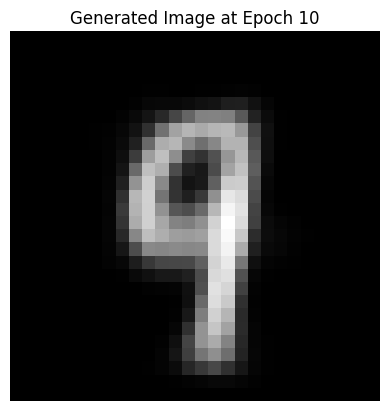

	Epoch 11 	Average Loss:  142.83216185504486
	Epoch 12 	Average Loss:  142.73141490700647
	Epoch 13 	Average Loss:  142.17230690473707
	Epoch 14 	Average Loss:  141.72386793744784
	Epoch 15 	Average Loss:  141.39626550435622
	Epoch 16 	Average Loss:  141.12331160658388
	Epoch 17 	Average Loss:  140.4328897772329
	Epoch 18 	Average Loss:  140.30093820103818
	Epoch 19 	Average Loss:  140.16144633960246
	Epoch 20 	Average Loss:  139.8175142979184


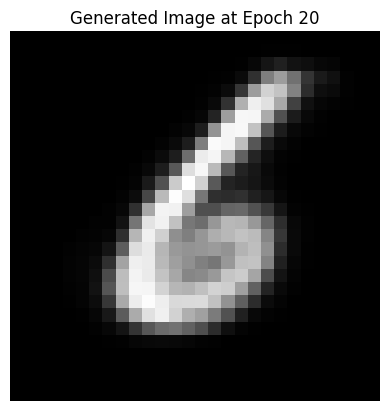

	Epoch 21 	Average Loss:  139.66485485248853
	Epoch 22 	Average Loss:  139.35285291566674
	Epoch 23 	Average Loss:  138.99936603323246
	Epoch 24 	Average Loss:  138.8758578424979
	Epoch 25 	Average Loss:  138.66553489213794
	Epoch 26 	Average Loss:  138.46530506573455
	Epoch 27 	Average Loss:  138.37385271024624
	Epoch 28 	Average Loss:  138.22135972062813
	Epoch 29 	Average Loss:  137.84828043483932
	Epoch 30 	Average Loss:  137.81843466324082


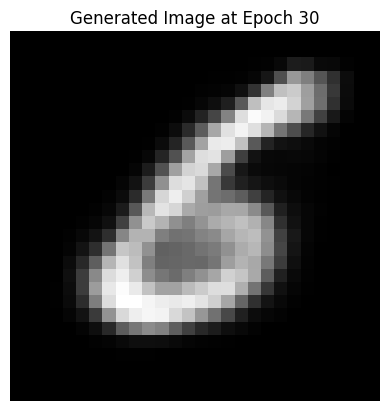

	Epoch 31 	Average Loss:  137.72787410984452
	Epoch 32 	Average Loss:  137.52001062969532
	Epoch 33 	Average Loss:  137.45382049509598
	Epoch 34 	Average Loss:  137.3922119222141
	Epoch 35 	Average Loss:  137.1923920890286
	Epoch 36 	Average Loss:  137.05747958837645
	Epoch 37 	Average Loss:  136.96878676374686
	Epoch 38 	Average Loss:  136.74722326925084
	Epoch 39 	Average Loss:  136.53237417179673
	Epoch 40 	Average Loss:  136.61659124256573


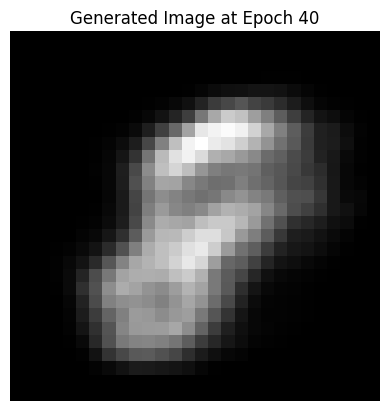

	Epoch 41 	Average Loss:  136.60379124713063
	Epoch 42 	Average Loss:  136.56538780454403
	Epoch 43 	Average Loss:  136.42057336772226
	Epoch 44 	Average Loss:  135.9808876121661
	Epoch 45 	Average Loss:  135.994369049327
	Epoch 46 	Average Loss:  135.9727090071995
	Epoch 47 	Average Loss:  136.03152200281718
	Epoch 48 	Average Loss:  136.09135963911206
	Epoch 49 	Average Loss:  135.9250179661415
	Epoch 50 	Average Loss:  135.82977809695848


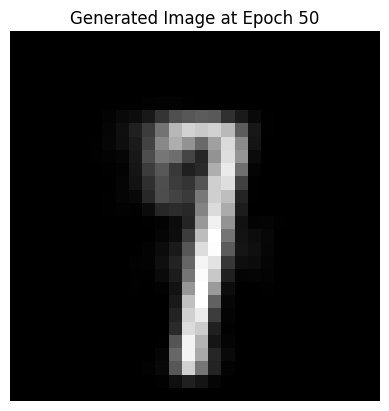

8136203.7080078125

In [9]:
train(model, optimizer, epochs=50, device=device)

# **Plot The Loss:**

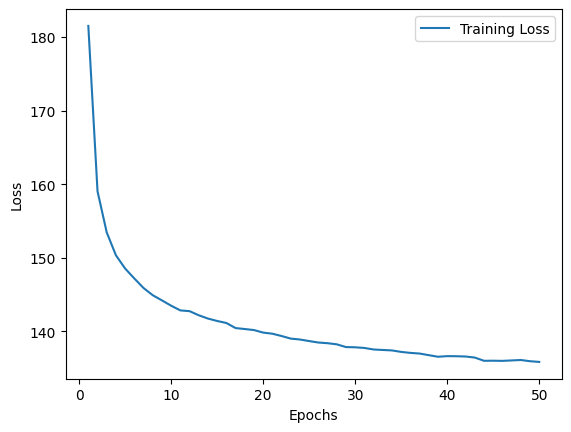

In [10]:
num_epochs=50
plt.plot(range(1,num_epochs+1) , losses ,label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Generate and plot digit

In [11]:
def generate_digit(mean, var):

    model.eval()
    mean=torch.full((model.decoder.fc1.in_features,),mean,dtype=torch.float32).to(device)
    var=torch.full((model.decoder.fc1.in_features,),var,dtype=torch.float32).to(device)

    with torch.no_grad():

      # convert var to standard deviation
      std=torch.sqrt(var)
      # sample epslion from random noise - N(0,1)
      eps=torch.randn_like(std).to(device)
      # apply reparameterziatrion trick : z=mean + eps*std
      z=mean+eps*std

      # pass the latent vector 'z' to the decoder.
      digit=model.decoder(z.unsqueeze(0)).cpu().view(28,28)


    def plot_digit(): # plot the generated digit
        # write your code here
        plt.imshow(digit,cmap='gray')
        plt.title(f"Generated digit (mu={mean[0].item()}, var={var[0].item()})")
        plt.axis('off')
        plt.show()

    plot_digit()

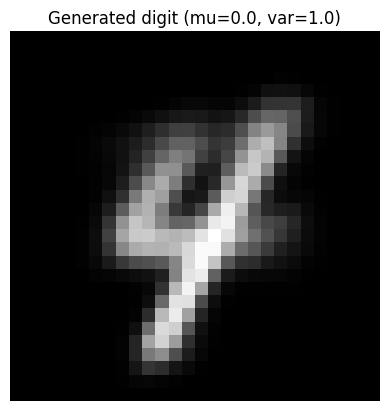

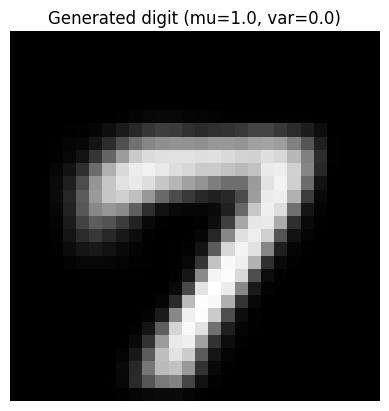

(None, None)

In [13]:
generate_digit(0.0, 1.0), generate_digit(1.0, 0.0)

# Latent Space Grid Visualization

In [14]:
def plot_latent_space(model, scale, digit_size=28, figsize=15):

    model.eval()
    grid_size=15

    # Generate a 2D grid of latent codes
    grid_x= np.linspace(-scale,scale,grid_size)
    grid_y=np.linspace(-scale,scale,grid_size)

    figure=np.zeros((digit_size*grid_size,digit_size*grid_size))

    for i,yi in enumerate(grid_y):
        for j,xi in enumerate(grid_x):

          # create latent vector (z1,z2)= (xi,yi)
          z=torch.tensor([[xi,yi]],dtype=torch.float32).to(device)


          with torch.no_grad():
            generated_image=model.decoder(z).squeeze().cpu().numpy().reshape(digit_size,digit_size)


            #Assign the generated image to the grid
            figure[i*digit_size:(i+1)* digit_size,
                   j*digit_size:(j+1)* digit_size]= generated_image



    #plot the grid of images
    plt.figure(figsize=(figsize,figsize))
    plt.imshow(figure,cmap="gray",extent=[-scale,scale,-scale,scale])
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.title(f"VAE Latent Space (Scale={scale})")
    plt.axis("on") # Show axes to visualize latent dimensions
    plt.show()

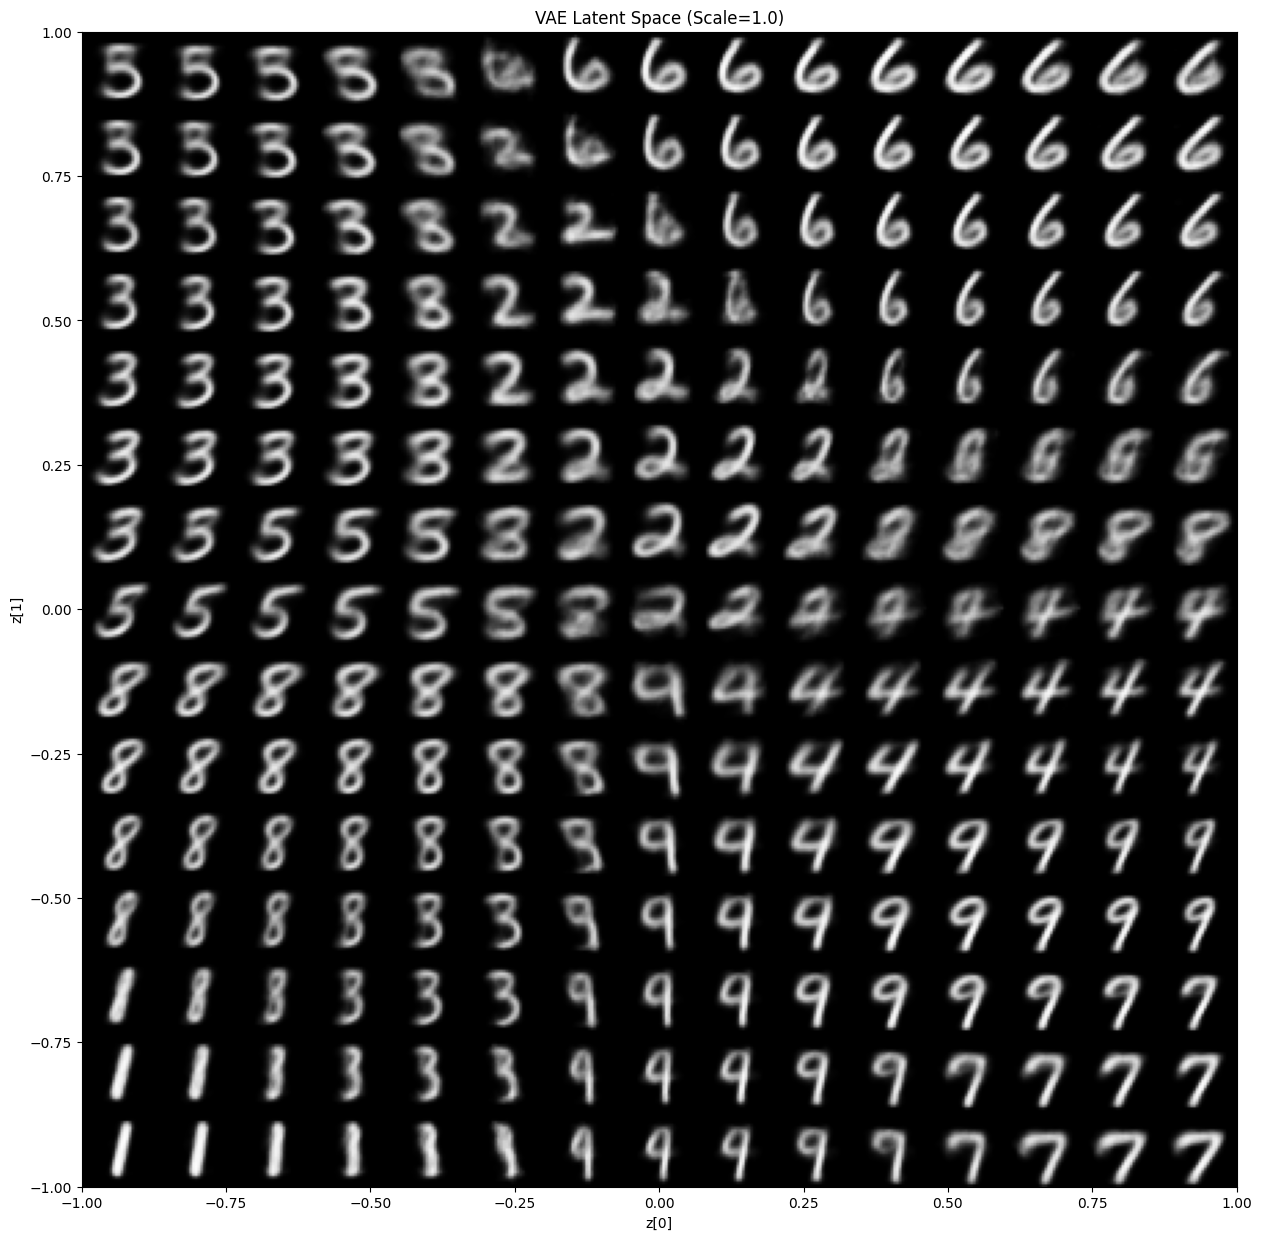

In [15]:
plot_latent_space(model, scale=1.0)

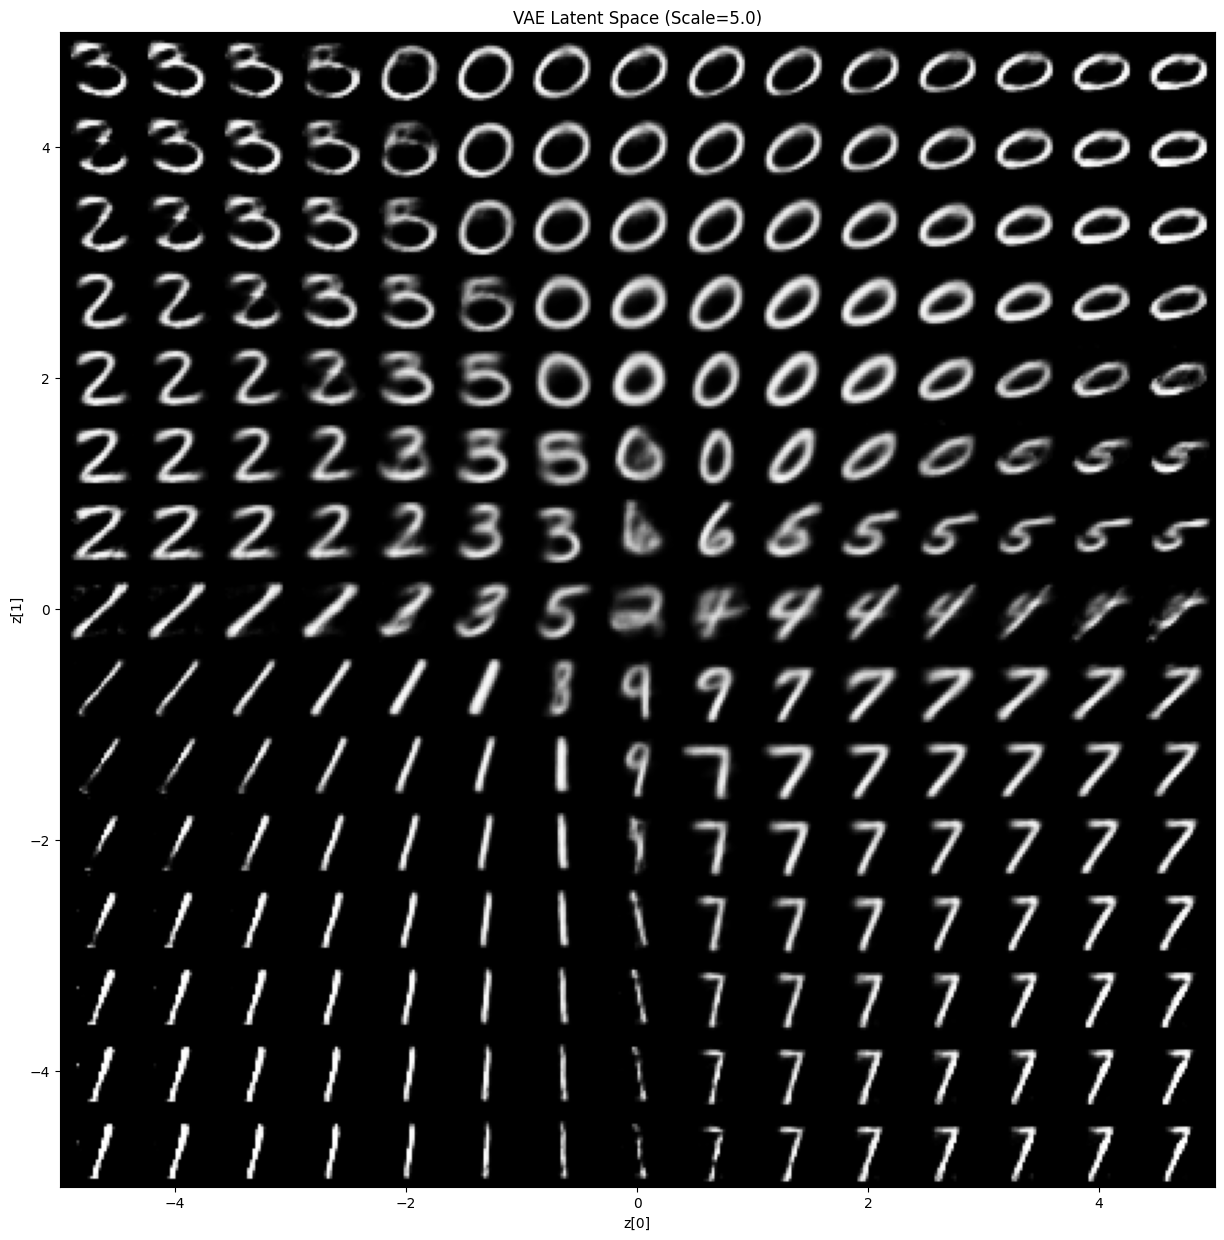

In [16]:
plot_latent_space(model, scale=5.0)

# Linear Interpolation

We defined the next function to apply linear interpolation between 2 randomly selected digits .

In [19]:
def linear_interpolation(model,dataset,num_steps=10):

  model.eval()
  device=next(model.parameters()).device

  # Step 1 : Randomly select two different classes
  labels=dataset.targets.numpy()
  unique_labels=np.unique(labels)
  label1,label2=np.random.choice(unique_labels,2,replace=False)



  #Step 2 : Randomly pick one image from each class
  idx1=np.random.choice(np.where(labels==label1)[0])
  idx2=np.random.choice(np.where(labels==label2)[0])


  img1,_=dataset[idx1]
  img2,_=dataset[idx2]

  #Step 3: Encode the latent codes
  img1=img1.view(1,-1).to(device)
  img2=img2.view(1,-1).to(device)

  with torch.no_grad():

    mu1,_= model.encoder(img1)
    mu2,_=model.encoder(img2)


  # Step 4: Linear interpolation between mu1 and mu2
  interpolated_zs=[mu1+(mu2-mu1)*t for t in torch.linspace(0,1,num_steps)]


  #Step 5: Decode the plot
  fig,axes=plt.subplots(1,num_steps,figsize=(20,2))
  for i,z in enumerate(interpolated_zs):

    with torch.no_grad():
      generated=model.decoder(z).squeeze().cpu().numpy().reshape(28,28)

    axes[i].imshow(generated,cmap="gray")
    axes[i].axis("off")

  plt.suptitle(f"Interpolation: Class {label1} → Class {label2}")
  plt.show()


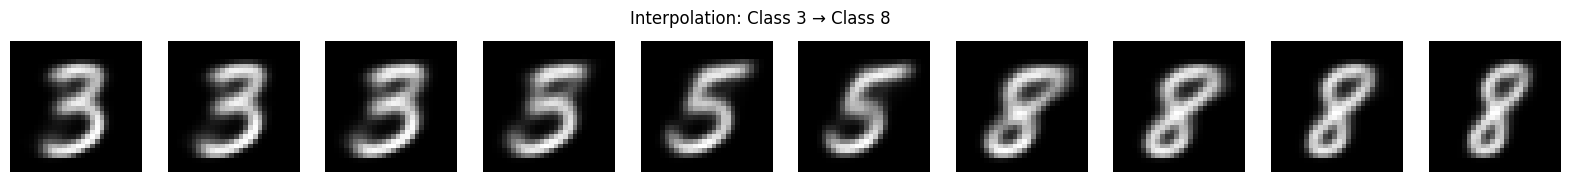

In [26]:
linear_interpolation(model, train_dataset, num_steps=10)

## BONUS Question
In this task, we visualized the learned latent space of a trained Variational Autoencoder (VAE) by generating a video of smooth transitions between digits.


In [40]:
def generate_interpolation_video(model,dataset,output_path="interpolation.mp4", num_steps=30,fps=10,resize_factor=10):

  os.makedirs("temp_frames", exist_ok=True)

  model.eval()
  device=next(model.parameters()).device
  labels=dataset.targets.numpy()
  unique_labels=np.unique(labels)
  label1,label2=np.random.choice(unique_labels,2,replace=False)


  #Randomly select images from the two classes
  idx1=np.random.choice(np.where(labels==label1)[0])
  idx2=np.random.choice(np.where(labels==label2)[0])
  img1,_=dataset[idx1]
  img2,_=dataset[idx2]

  #Encode to latent vectors
  img1=img1.view(1,-1).to(device)
  img2=img2.view(1,-1).to(device)

  with torch.no_grad():
    mu1,_=model.encoder(img1)
    mu2,_=model.encoder(img2)


  #Generate and save frames
  frames=[]
  for t in np.linspace(0,1,num_steps):

    z=mu1+(mu2-mu1)*t

    with torch.no_grad():
      generated=model.decoder(z).squeeze().cpu().numpy().reshape(28,28)


      #Resize for better visibility
      generated=generated.repeat(resize_factor,axis=0).repeat(resize_factor,axis=1)
      frames.append((generated * 255).astype(np.uint8))  # Scale to 0-255



  # Save frames as video
  imageio.mimsave(output_path,frames,fps=fps,codec="libx264")
  print(f"Video saved to {output_path}")



In [43]:
# After training the VAE
generate_interpolation_video(
    model,
    train_dataset,
    output_path="digit_interpolation.mp4",
    num_steps=60,  # More steps = smoother video
    fps=20,         # Higher FPS = faster playback
    resize_factor=10 # 28x28 → 280x280 pixels
)

Video saved to digit_interpolation.mp4


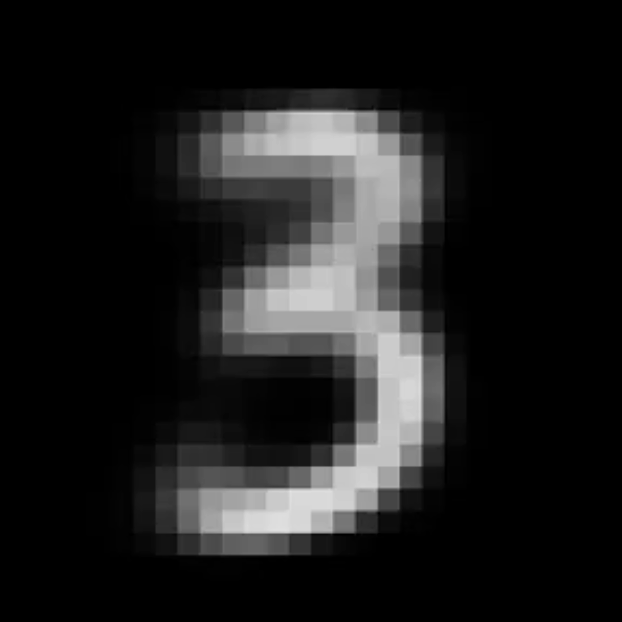

# **MODEL - SUMMARY :**

In [42]:
# Print the network summary
print(model)

# Function to calculate the number of trainable parameters
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Calculate the number of trainable parameters
total_params = count_trainable_parameters(model)

print(f'Total trainable parameters: {total_params}')

VAE(
  (encoder): Encoder(
    (fc1): Linear(in_features=784, out_features=400, bias=True)
    (fc2): Linear(in_features=400, out_features=400, bias=True)
    (mu): Linear(in_features=400, out_features=2, bias=True)
    (log_var): Linear(in_features=400, out_features=2, bias=True)
  )
  (decoder): Decoder(
    (fc1): Linear(in_features=2, out_features=400, bias=True)
    (fc2): Linear(in_features=400, out_features=400, bias=True)
    (fc3): Linear(in_features=400, out_features=784, bias=True)
  )
)
Total trainable parameters: 951988
